In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### DATA LOADING AND INITIAL EXPLORATION

In [21]:
df = pd.read_csv('D:\Private\Python\data\datasets\A.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-11-18,32.546494,35.765381,28.612303,31.473534,27.068665,62546300
1,1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100
2,1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800
3,1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600
4,1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200
...,...,...,...,...,...,...,...
5119,2020-03-26,70.000000,74.449997,69.650002,73.720001,73.532867,3267500
5120,2020-03-27,71.550003,73.209999,70.279999,70.910004,70.730003,1829800
5121,2020-03-30,71.059998,73.180000,71.059998,72.669998,72.669998,1486200
5122,2020-03-31,72.339996,72.800003,70.500000,71.620003,71.620003,1822100


In [22]:
df.sample(10)

,Date,Open,High,Low,Close,Adj Close,Volume
630,2002-05-28,19.563662,19.949928,19.248926,19.413448,16.696444,1857100
1035,2004-01-05,21.101574,21.144491,20.894135,21.137339,18.179064,5234500
4742,2018-09-25,70.169998,70.830002,69.910004,70.379997,69.288795,2090200
1069,2004-02-24,23.962805,24.391989,23.748211,24.141630,20.762890,6072200
2598,2010-03-22,23.791130,24.198856,23.669527,24.120173,22.016579,3946600
1044,2004-01-16,23.547926,24.585121,23.426323,24.499285,21.070498,5920300
2773,2010-11-29,25.715307,25.758226,25.257511,25.500715,23.276722,4813000
2964,2011-08-31,26.294706,27.224607,26.072962,26.373390,24.073286,7548600
1261,2004-11-26,16.494993,16.709585,16.487841,16.566525,14.247962,866700
991,2003-10-30,17.346209,18.104435,17.303291,17.746780,15.263033,6588400


In [23]:
print(df.describe())

              Open         High          Low        Close    Adj Close  \
count  5124.000000  5124.000000  5124.000000  5124.000000  5124.000000   
mean     34.090255    34.560553    33.629467    34.106245    31.778674   
std      18.608831    18.834528    18.381718    18.611595    18.730529   
min       7.653791     7.961373     7.510730     7.761087     6.674886   
25%      21.101574    21.452074    20.785050    21.130186    18.790381   
50%      27.328326    27.703863    27.010015    27.396280    24.714866   
75%      41.500000    41.860001    41.130001    41.525204    39.203083   
max     111.587982   115.879829   103.719597   113.733902    97.816307   

             Volume  
count  5.124000e+03  
mean   3.693250e+06  
std    2.481855e+06  
min    2.719000e+05  
25%    2.206475e+06  
50%    3.174050e+06  
75%    4.508075e+06  
max    6.254630e+07  


In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
print("Dataset Overview:")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   Trading Days: {len(df)}")
print(f"   Approximate Years: {len(df)/252:.1f}")

Dataset Overview:
   Shape: 5124 rows × 7 columns
   Date Range: 1999-11-18 to 2020-04-01
   Trading Days: 5124
   Approximate Years: 20.3


In [26]:
print("Price Statistics:")
print(f"   Close Price - Mean: ${df['Close'].mean():.2f}")
print(f"   Close Price - Min: ${df['Close'].min():.2f}")
print(f"   Close Price - Max: ${df['Close'].max():.2f}")
print(f"   Total Return: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%")


Price Statistics:
   Close Price - Mean: $34.11
   Close Price - Min: $7.76
   Close Price - Max: $113.73
   Total Return: 118.98%


In [27]:
print("Data Quality Check:")
missing = df.isnull().sum()
print(f"   Missing Values: {missing.sum()} total")
if missing.sum() > 0:
    print("   Missing by column:")
    print(missing[missing > 0])

Data Quality Check:
   Missing Values: 0 total


### Feature Engineering

In [28]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
df['Overnight_Return'] = (df['Open'] / df['Close'].shift(1) - 1) * 100
df['Intraday_Return'] = (df['Close'] / df['Open'] - 1) * 100
df['High_Low_Spread'] = ((df['High'] - df['Low']) / df['Open']) * 100
df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_20']
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()
df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()
df['RSI'] = 100 - (100 / (1 + df['Close'].pct_change().rolling(14).apply(
    lambda x: x[x > 0].mean() / abs(x[x < 0].mean()) if len(x[x < 0]) > 0 else 0)))

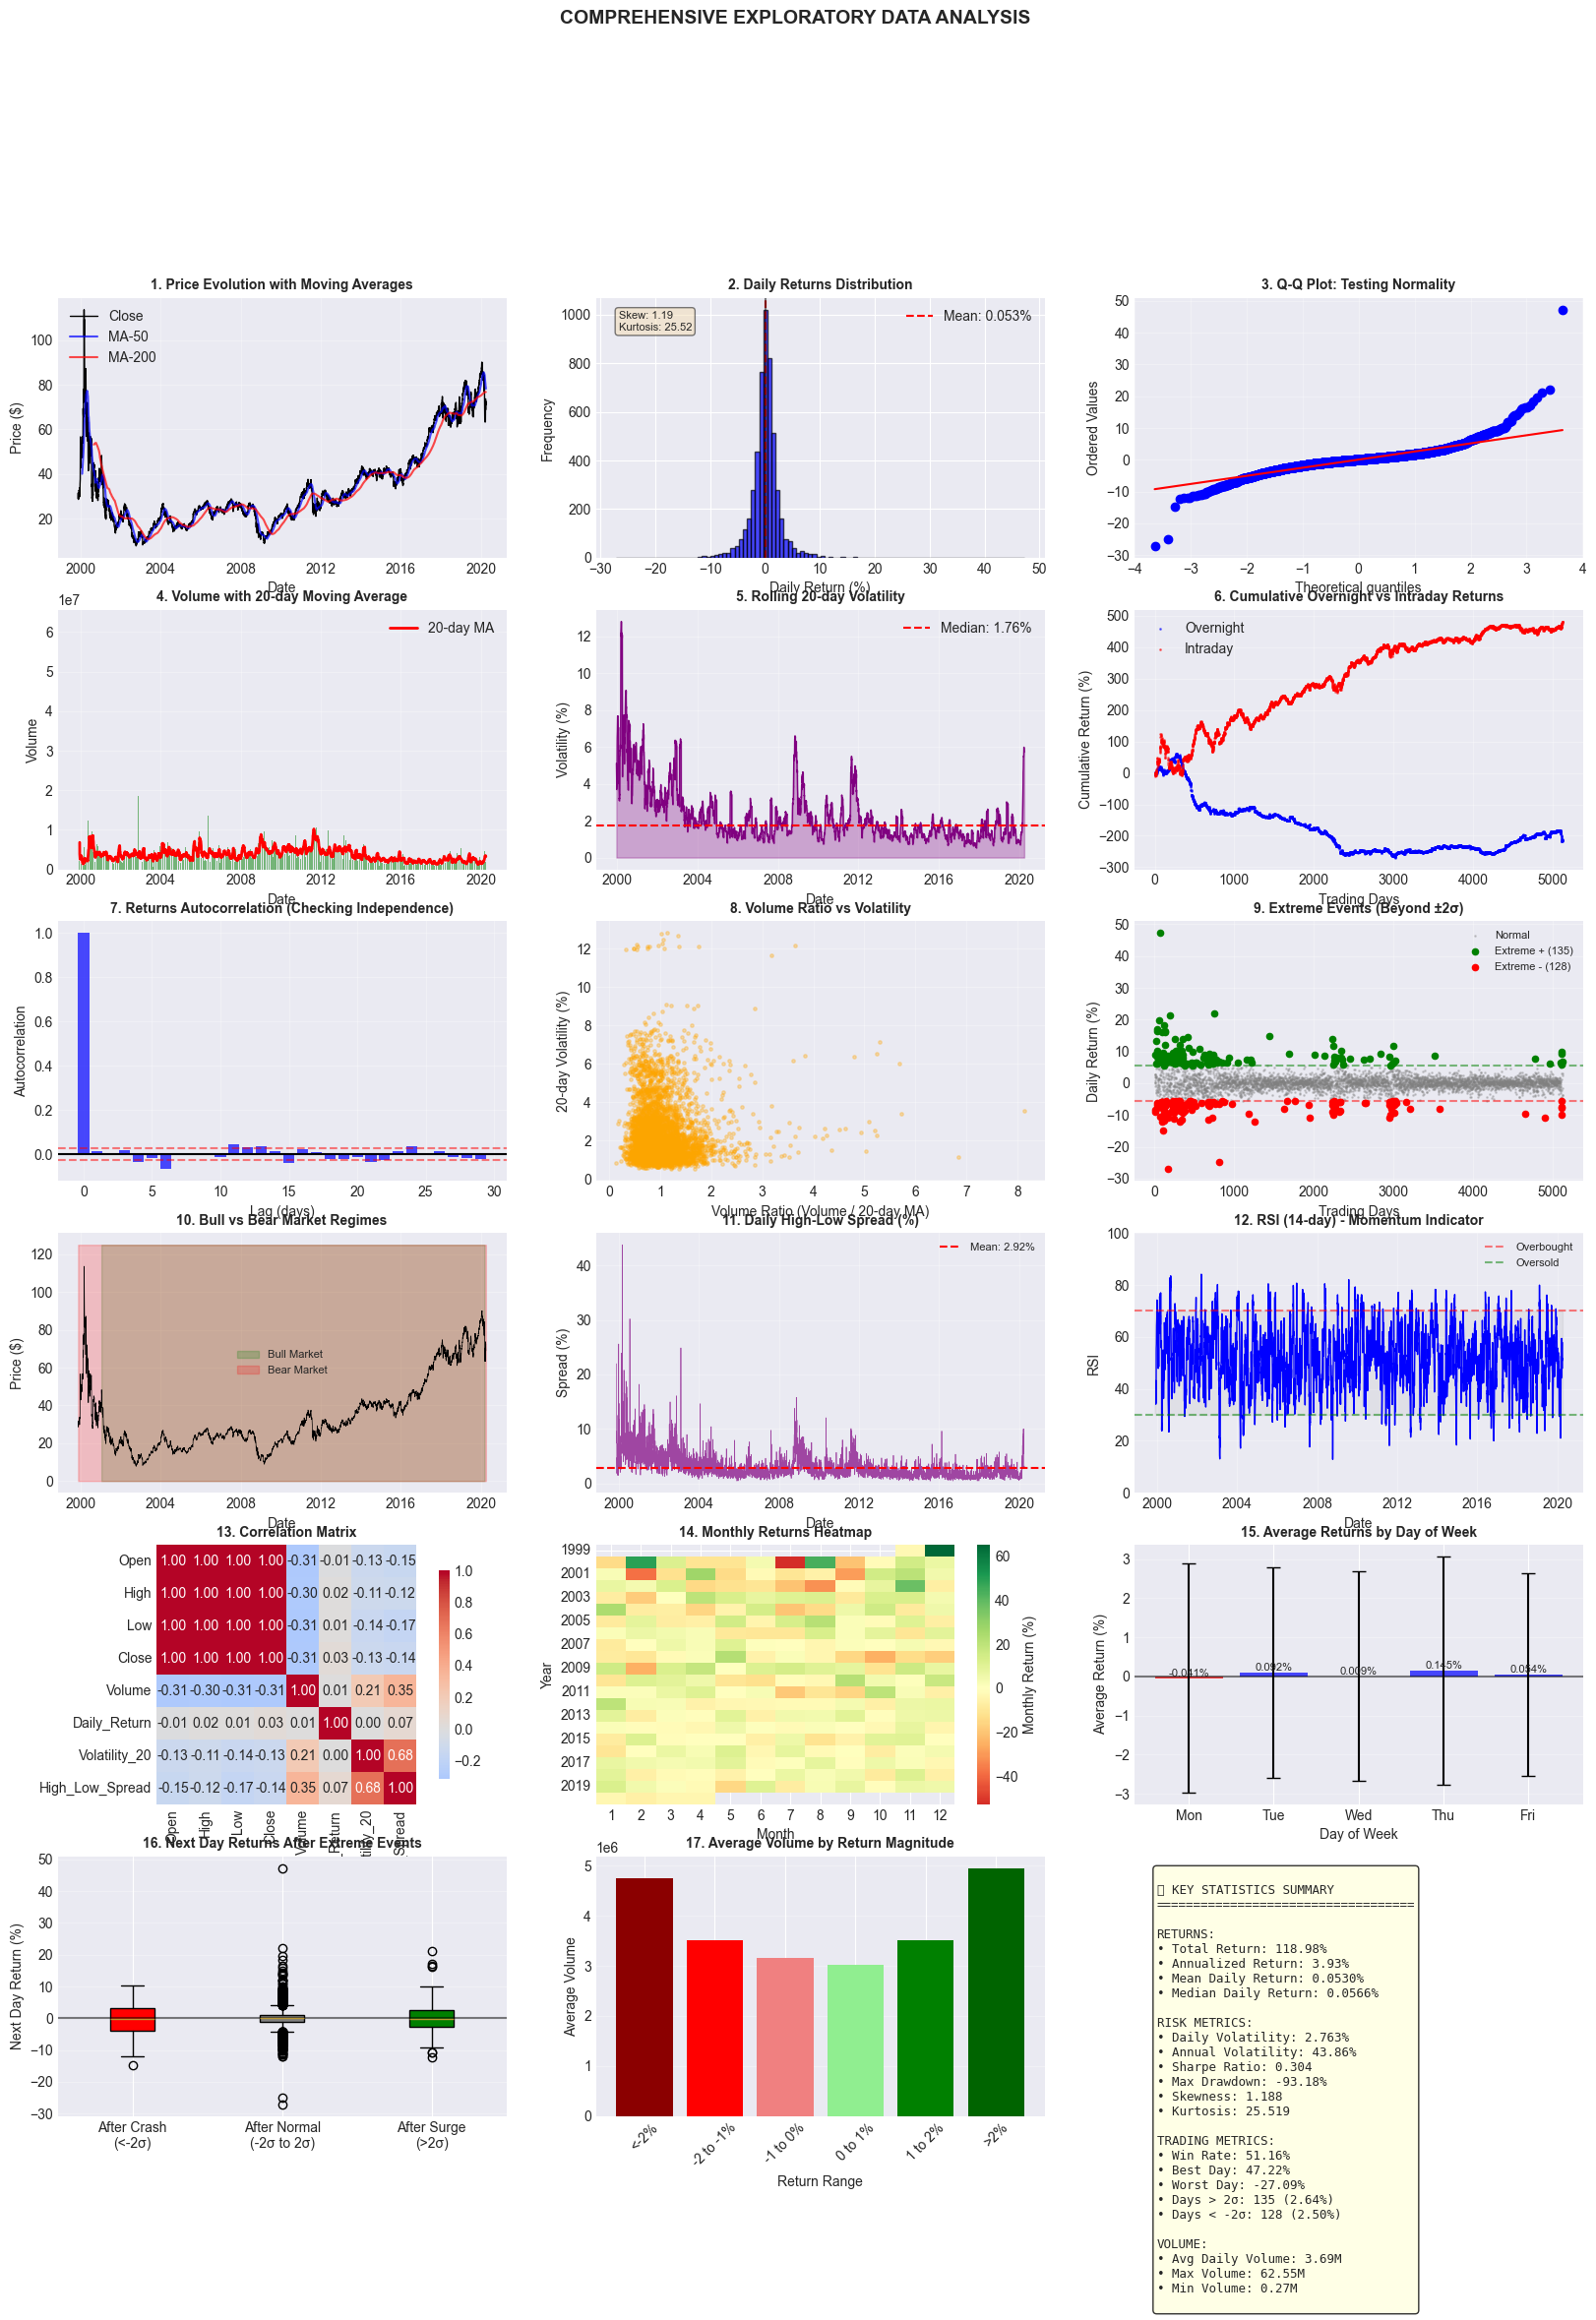

In [29]:
# Create comprehensive visualization
fig = plt.figure(figsize=(20, 24))

# 1. Price Chart with Moving Averages
ax1 = plt.subplot(6, 3, 1)
ax1.plot(df['Date'], df['Close'], label='Close', linewidth=1, color='black')
ax1.plot(df['Date'], df['MA_50'], label='MA-50', alpha=0.7, color='blue')
ax1.plot(df['Date'], df['MA_200'], label='MA-200', alpha=0.7, color='red')
ax1.set_title('1. Price Evolution with Moving Averages', fontweight='bold', fontsize=10)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Returns Distribution
ax2 = plt.subplot(6, 3, 2)
returns_clean = df['Daily_Return'].dropna()
ax2.hist(returns_clean, bins=100, edgecolor='black', alpha=0.7, color='blue')
ax2.axvline(returns_clean.mean(), color='red', linestyle='--', label=f'Mean: {returns_clean.mean():.3f}%')
ax2.axvline(0, color='black', linestyle='-', alpha=0.5)
ax2.set_title('2. Daily Returns Distribution', fontweight='bold', fontsize=10)
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.legend()
skew = stats.skew(returns_clean)
kurt = stats.kurtosis(returns_clean)
ax2.text(0.05, 0.95, f'Skew: {skew:.2f}\nKurtosis: {kurt:.2f}', 
         transform=ax2.transAxes, fontsize=8, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 3. Q-Q Plot for Normality
ax3 = plt.subplot(6, 3, 3)
stats.probplot(returns_clean, dist="norm", plot=ax3)
ax3.set_title('3. Q-Q Plot: Testing Normality', fontweight='bold', fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Volume Analysis
ax4 = plt.subplot(6, 3, 4)
ax4.bar(df['Date'], df['Volume'], width=1, alpha=0.5, color='green')
ax4.plot(df['Date'], df['Volume_MA_20'], color='red', linewidth=2, label='20-day MA')
ax4.set_title('4. Volume with 20-day Moving Average', fontweight='bold', fontsize=10)
ax4.set_xlabel('Date')
ax4.set_ylabel('Volume')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Volatility Over Time
ax5 = plt.subplot(6, 3, 5)
ax5.plot(df['Date'], df['Volatility_20'], color='purple', linewidth=1)
ax5.fill_between(df['Date'], 0, df['Volatility_20'], alpha=0.3, color='purple')
median_vol = df['Volatility_20'].median()
ax5.axhline(median_vol, color='red', linestyle='--', label=f'Median: {median_vol:.2f}%')
ax5.set_title('5. Rolling 20-day Volatility', fontweight='bold', fontsize=10)
ax5.set_xlabel('Date')
ax5.set_ylabel('Volatility (%)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Overnight vs Intraday Returns
ax6 = plt.subplot(6, 3, 6)
overnight_clean = df['Overnight_Return'].dropna()
intraday_clean = df['Intraday_Return'].dropna()
ax6.scatter(overnight_clean.index, overnight_clean.cumsum(), alpha=0.5, s=1, label='Overnight', color='blue')
ax6.scatter(intraday_clean.index, intraday_clean.cumsum(), alpha=0.5, s=1, label='Intraday', color='red')
ax6.set_title('6. Cumulative Overnight vs Intraday Returns', fontweight='bold', fontsize=10)
ax6.set_xlabel('Trading Days')
ax6.set_ylabel('Cumulative Return (%)')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Returns Autocorrelation
ax7 = plt.subplot(6, 3, 7)
lags = 30
autocorr = [returns_clean.autocorr(lag) for lag in range(lags)]
ax7.bar(range(lags), autocorr, color='blue', alpha=0.7)
ax7.axhline(0, color='black', linestyle='-')
ax7.axhline(1.96/np.sqrt(len(returns_clean)), color='red', linestyle='--', alpha=0.5)
ax7.axhline(-1.96/np.sqrt(len(returns_clean)), color='red', linestyle='--', alpha=0.5)
ax7.set_title('7. Returns Autocorrelation (Checking Independence)', fontweight='bold', fontsize=10)
ax7.set_xlabel('Lag (days)')
ax7.set_ylabel('Autocorrelation')
ax7.grid(True, alpha=0.3)

# 8. Volume vs Volatility Relationship  (FIXED)
ax8 = plt.subplot(6, 3, 8)

pair = (
    df[['Volume_Ratio', 'Volatility_20']]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

ax8.scatter(
    pair['Volume_Ratio'].values,
    pair['Volatility_20'].values,
    alpha=0.3, s=6, color='orange'
)

ax8.set_title('8. Volume Ratio vs Volatility', fontweight='bold', fontsize=10)
ax8.set_xlabel('Volume Ratio (Volume / 20-day MA)')
ax8.set_ylabel('20-day Volatility (%)')
ax8.grid(True, alpha=0.3)

# 9. Extreme Events Analysis
ax9 = plt.subplot(6, 3, 9)
threshold = 2 * returns_clean.std()
extreme_positive = returns_clean[returns_clean > threshold]
extreme_negative = returns_clean[returns_clean < -threshold]
ax9.scatter(df.index, df['Daily_Return'], alpha=0.3, s=1, color='gray', label='Normal')
ax9.scatter(extreme_positive.index, extreme_positive, color='green', s=20, label=f'Extreme + ({len(extreme_positive)})')
ax9.scatter(extreme_negative.index, extreme_negative, color='red', s=20, label=f'Extreme - ({len(extreme_negative)})')
ax9.axhline(threshold, color='green', linestyle='--', alpha=0.5)
ax9.axhline(-threshold, color='red', linestyle='--', alpha=0.5)
ax9.set_title('9. Extreme Events (Beyond ±2σ)', fontweight='bold', fontsize=10)
ax9.set_xlabel('Trading Days')
ax9.set_ylabel('Daily Return (%)')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3)

# 10. Bull vs Bear Market Identification
ax10 = plt.subplot(6, 3, 10)
df['Bull_Market'] = df['Close'] > df['MA_200']
bull_periods = df[df['Bull_Market'] == True].index
bear_periods = df[df['Bull_Market'] == False].index
ax10.plot(df['Date'], df['Close'], color='black', linewidth=0.5)
ax10.fill_between(df['Date'].iloc[bull_periods], 0, df['Close'].max()*1.1, 
                  alpha=0.2, color='green', label='Bull Market')
ax10.fill_between(df['Date'].iloc[bear_periods], 0, df['Close'].max()*1.1, 
                  alpha=0.2, color='red', label='Bear Market')
ax10.set_title('10. Bull vs Bear Market Regimes', fontweight='bold', fontsize=10)
ax10.set_xlabel('Date')
ax10.set_ylabel('Price ($)')
ax10.legend(fontsize=8)
ax10.grid(True, alpha=0.3)

# 11. High-Low Spread (Daily Range)
ax11 = plt.subplot(6, 3, 11)
ax11.plot(df['Date'], df['High_Low_Spread'], linewidth=0.5, color='purple', alpha=0.7)
ax11.axhline(df['High_Low_Spread'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df['High_Low_Spread'].mean():.2f}%")
ax11.set_title('11. Daily High-Low Spread (%)', fontweight='bold', fontsize=10)
ax11.set_xlabel('Date')
ax11.set_ylabel('Spread (%)')
ax11.legend(fontsize=8)
ax11.grid(True, alpha=0.3)

# 12. RSI Indicator
ax12 = plt.subplot(6, 3, 12)
ax12.plot(df['Date'], df['RSI'], linewidth=1, color='blue')
ax12.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
ax12.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
ax12.fill_between(df['Date'], 30, 70, alpha=0.1, color='gray')
ax12.set_title('12. RSI (14-day) - Momentum Indicator', fontweight='bold', fontsize=10)
ax12.set_xlabel('Date')
ax12.set_ylabel('RSI')
ax12.set_ylim([0, 100])
ax12.legend(fontsize=8)
ax12.grid(True, alpha=0.3)

# 13. Correlation Heatmap
ax13 = plt.subplot(6, 3, 13)
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 
             'Volatility_20', 'High_Low_Spread']
corr_data = df[corr_cols].dropna()
corr_matrix = corr_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax13, cbar_kws={"shrink": 0.8})
ax13.set_title('13. Correlation Matrix', fontweight='bold', fontsize=10)

# 14. Monthly Returns Heatmap
ax14 = plt.subplot(6, 3, 14)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
monthly_returns = df.groupby(['Year', 'Month'])['Daily_Return'].sum().unstack()
sns.heatmap(monthly_returns, cmap='RdYlGn', center=0, ax=ax14, 
            cbar_kws={'label': 'Monthly Return (%)'})
ax14.set_title('14. Monthly Returns Heatmap', fontweight='bold', fontsize=10)
ax14.set_xlabel('Month')
ax14.set_ylabel('Year')

# 15. Day of Week Analysis
ax15 = plt.subplot(6, 3, 15)
df['DayOfWeek'] = df['Date'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
daily_avg_returns = df.groupby('DayOfWeek')['Daily_Return'].mean()
daily_std_returns = df.groupby('DayOfWeek')['Daily_Return'].std()
x_pos = np.arange(5)
bars = ax15.bar(x_pos, daily_avg_returns[:5], yerr=daily_std_returns[:5], 
               capsize=5, alpha=0.7, color=['red' if i == 0 else 'blue' for i in range(5)])
ax15.set_xticks(x_pos)
ax15.set_xticklabels(day_names)
ax15.axhline(0, color='black', linestyle='-', alpha=0.5)
ax15.set_title('15. Average Returns by Day of Week', fontweight='bold', fontsize=10)
ax15.set_xlabel('Day of Week')
ax15.set_ylabel('Average Return (%)')
ax15.grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, daily_avg_returns[:5])):
    ax15.text(bar.get_x() + bar.get_width()/2, val + 0.001, f'{val:.3f}%', 
             ha='center', va='bottom', fontsize=8)

# 16. Returns After Extreme Days
ax16 = plt.subplot(6, 3, 16)
df['Next_Return'] = df['Daily_Return'].shift(-1)
extreme_up = df[df['Daily_Return'] > threshold]['Next_Return'].dropna()
extreme_down = df[df['Daily_Return'] < -threshold]['Next_Return'].dropna()
normal_days = df[(df['Daily_Return'] >= -threshold) & (df['Daily_Return'] <= threshold)]['Next_Return'].dropna()

bp = ax16.boxplot([extreme_down, normal_days, extreme_up], 
                  labels=['After Crash\n(<-2σ)', 'After Normal\n(-2σ to 2σ)', 'After Surge\n(>2σ)'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('red')
bp['boxes'][1].set_facecolor('gray')
bp['boxes'][2].set_facecolor('green')
ax16.axhline(0, color='black', linestyle='-', alpha=0.5)
ax16.set_title('16. Next Day Returns After Extreme Events', fontweight='bold', fontsize=10)
ax16.set_ylabel('Next Day Return (%)')
ax16.grid(True, alpha=0.3, axis='y')

# 17. Volume Profile by Return Magnitude
ax17 = plt.subplot(6, 3, 17)
df['Return_Bucket'] = pd.cut(df['Daily_Return'], bins=[-np.inf, -2, -1, 0, 1, 2, np.inf],
                             labels=['<-2%', '-2 to -1%', '-1 to 0%', '0 to 1%', '1 to 2%', '>2%'])
volume_by_return = df.groupby('Return_Bucket')['Volume'].mean()
ax17.bar(range(len(volume_by_return)), volume_by_return.values, 
        color=['darkred', 'red', 'lightcoral', 'lightgreen', 'green', 'darkgreen'])
ax17.set_xticks(range(len(volume_by_return)))
ax17.set_xticklabels(volume_by_return.index, rotation=45)
ax17.set_title('17. Average Volume by Return Magnitude', fontweight='bold', fontsize=10)
ax17.set_xlabel('Return Range')
ax17.set_ylabel('Average Volume')
ax17.grid(True, alpha=0.3, axis='y')

# 18. Summary Statistics Panel
ax18 = plt.subplot(6, 3, 18)
ax18.axis('off')

# Calculate summary statistics
total_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
annual_return = (((df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (252/len(df))) - 1) * 100
sharpe_ratio = (df['Daily_Return'].mean() / df['Daily_Return'].std()) * np.sqrt(252)
max_drawdown = ((df['Close'] / df['Close'].cummax()) - 1).min() * 100
win_rate = (df['Daily_Return'] > 0).sum() / df['Daily_Return'].notna().sum() * 100

summary_text = f"""
📊 KEY STATISTICS SUMMARY
{'='*35}

RETURNS:
• Total Return: {total_return:.2f}%
• Annualized Return: {annual_return:.2f}%
• Mean Daily Return: {df['Daily_Return'].mean():.4f}%
• Median Daily Return: {df['Daily_Return'].median():.4f}%

RISK METRICS:
• Daily Volatility: {df['Daily_Return'].std():.3f}%
• Annual Volatility: {df['Daily_Return'].std() * np.sqrt(252):.2f}%
• Sharpe Ratio: {sharpe_ratio:.3f}
• Max Drawdown: {max_drawdown:.2f}%
• Skewness: {skew:.3f}
• Kurtosis: {kurt:.3f}

TRADING METRICS:
• Win Rate: {win_rate:.2f}%
• Best Day: {df['Daily_Return'].max():.2f}%
• Worst Day: {df['Daily_Return'].min():.2f}%
• Days > 2σ: {len(extreme_positive)} ({len(extreme_positive)/len(returns_clean)*100:.2f}%)
• Days < -2σ: {len(extreme_negative)} ({len(extreme_negative)/len(returns_clean)*100:.2f}%)

VOLUME:
• Avg Daily Volume: {df['Volume'].mean()/1e6:.2f}M
• Max Volume: {df['Volume'].max()/1e6:.2f}M
• Min Volume: {df['Volume'].min()/1e6:.2f}M
"""

ax18.text(0.05, 0.95, summary_text, transform=ax18.transAxes, fontsize=9,
         verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('COMPREHENSIVE EXPLORATORY DATA ANALYSIS', fontsize=14, fontweight='bold', y=1.002)
plt.show()


In [30]:
print("\n" + "="*80)
print("PHASE 4: ANOMALY DETECTION")
print("="*80)

print("\n🔴 KEY OBSERVATIONS FROM EDA:")

# Calculate statistics
skew = stats.skew(returns_clean)
kurt = stats.kurtosis(returns_clean)

# 1. Distribution Analysis
print("\n1. RETURN DISTRIBUTION ANOMALIES:")
print(f"   • Skewness: {skew:.3f} {'(Negative skew - more crashes)' if skew < -0.5 else '(Positive skew - more surges)' if skew > 0.5 else '(Relatively symmetric)'}")
print(f"   • Excess Kurtosis: {kurt:.3f} {'(Fat tails - extreme events)' if kurt > 1 else '(Normal tails)' if kurt < 1 else ''}")
print(f"   • Mean Return: {returns_clean.mean():.4f}% {'(Positive drift)' if returns_clean.mean() > 0.01 else '(Negative drift)' if returns_clean.mean() < -0.01 else '(No drift)'}")

# 2. Volatility Clustering
vol_autocorr = df['Volatility_20'].dropna().autocorr(1)
print(f"\n2. VOLATILITY CLUSTERING:")
print(f"   • Volatility autocorrelation: {vol_autocorr:.3f}")
print(f"   • Interpretation: {'Strong clustering' if abs(vol_autocorr) > 0.5 else 'Moderate clustering' if abs(vol_autocorr) > 0.3 else 'Weak clustering'}")

# 3. Extreme Events
threshold = 2 * returns_clean.std()
extreme_positive = returns_clean[returns_clean > threshold]
extreme_negative = returns_clean[returns_clean < -threshold]
print(f"\n3. TAIL RISK ASYMMETRY:")
print(f"   • Extreme positive days (>2σ): {len(extreme_positive)}")
print(f"   • Extreme negative days (<-2σ): {len(extreme_negative)}")
print(f"   • Asymmetry ratio: {len(extreme_negative)/len(extreme_positive) if len(extreme_positive) > 0 else 'inf':.2f}")

# 4. Day of Week Effect
daily_avg_returns = df.groupby('DayOfWeek')['Daily_Return'].mean()
monday_return = daily_avg_returns[0]
other_avg = daily_avg_returns[1:5].mean()
print(f"\n4. DAY-OF-WEEK ANOMALY:")
print(f"   • Monday average: {monday_return:.4f}%")
print(f"   • Other days average: {other_avg:.4f}%")
print(f"   • Monday effect: {monday_return - other_avg:.4f}%")

# 5. Overnight vs Intraday
overnight_total = df['Overnight_Return'].sum()
intraday_total = df['Intraday_Return'].sum()
print(f"\n5. OVERNIGHT ANOMALY:")
print(f"   • Total overnight return: {overnight_total:.2f}%")
print(f"   • Total intraday return: {intraday_total:.2f}%")
print(f"   • Overnight dominance: {overnight_total/(overnight_total+intraday_total)*100:.1f}% of total returns")



PHASE 4: ANOMALY DETECTION

🔴 KEY OBSERVATIONS FROM EDA:

1. RETURN DISTRIBUTION ANOMALIES:
   • Skewness: 1.188 (Positive skew - more surges)
   • Excess Kurtosis: 25.519 (Fat tails - extreme events)
   • Mean Return: 0.0530% (Positive drift)

2. VOLATILITY CLUSTERING:
   • Volatility autocorrelation: 0.988
   • Interpretation: Strong clustering

3. TAIL RISK ASYMMETRY:
   • Extreme positive days (>2σ): 135
   • Extreme negative days (<-2σ): 128
   • Asymmetry ratio: 0.95

4. DAY-OF-WEEK ANOMALY:
   • Monday average: -0.0407%
   • Other days average: 0.0749%
   • Monday effect: -0.1156%

5. OVERNIGHT ANOMALY:
   • Total overnight return: -217.71%
   • Total intraday return: 480.26%
   • Overnight dominance: -82.9% of total returns


In [31]:
print("\n" + "="*80)
print("PHASE 4: ANOMALY DETECTION")
print("="*80)

print("\n🔴 KEY OBSERVATIONS FROM EDA:")

# Calculate statistics
skew = stats.skew(returns_clean)
kurt = stats.kurtosis(returns_clean)

# 1. Distribution Analysis
print("\n1. RETURN DISTRIBUTION ANOMALIES:")
print(f"   • Skewness: {skew:.3f} {'(Negative skew - more crashes)' if skew < -0.5 else '(Positive skew - more surges)' if skew > 0.5 else '(Relatively symmetric)'}")
print(f"   • Excess Kurtosis: {kurt:.3f} {'(Fat tails - extreme events)' if kurt > 1 else '(Normal tails)' if kurt < 1 else ''}")
print(f"   • Mean Return: {returns_clean.mean():.4f}% {'(Positive drift)' if returns_clean.mean() > 0.01 else '(Negative drift)' if returns_clean.mean() < -0.01 else '(No drift)'}")




PHASE 4: ANOMALY DETECTION

🔴 KEY OBSERVATIONS FROM EDA:

1. RETURN DISTRIBUTION ANOMALIES:
   • Skewness: 1.188 (Positive skew - more surges)
   • Excess Kurtosis: 25.519 (Fat tails - extreme events)
   • Mean Return: 0.0530% (Positive drift)


In [32]:
# 2. Volatility Clustering
vol_autocorr = df['Volatility_20'].dropna().autocorr(1)
print(f"\n2. VOLATILITY CLUSTERING:")
print(f"   • Volatility autocorrelation: {vol_autocorr:.3f}")
print(f"   • Interpretation: {'Strong clustering' if abs(vol_autocorr) > 0.5 else 'Moderate clustering' if abs(vol_autocorr) > 0.3 else 'Weak clustering'}")




2. VOLATILITY CLUSTERING:
   • Volatility autocorrelation: 0.988
   • Interpretation: Strong clustering


In [33]:
# 3. Extreme Events
threshold = 2 * returns_clean.std()
extreme_positive = returns_clean[returns_clean > threshold]
extreme_negative = returns_clean[returns_clean < -threshold]
print(f"\n3. TAIL RISK ASYMMETRY:")
print(f"   • Extreme positive days (>2σ): {len(extreme_positive)}")
print(f"   • Extreme negative days (<-2σ): {len(extreme_negative)}")
print(f"   • Asymmetry ratio: {len(extreme_negative)/len(extreme_positive) if len(extreme_positive) > 0 else 'inf':.2f}")




3. TAIL RISK ASYMMETRY:
   • Extreme positive days (>2σ): 135
   • Extreme negative days (<-2σ): 128
   • Asymmetry ratio: 0.95


In [34]:
# 4. Day of Week Effect
daily_avg_returns = df.groupby('DayOfWeek')['Daily_Return'].mean()
monday_return = daily_avg_returns[0]
other_avg = daily_avg_returns[1:5].mean()
print(f"\n4. DAY-OF-WEEK ANOMALY:")
print(f"   • Monday average: {monday_return:.4f}%")
print(f"   • Other days average: {other_avg:.4f}%")
print(f"   • Monday effect: {monday_return - other_avg:.4f}%")




4. DAY-OF-WEEK ANOMALY:
   • Monday average: -0.0407%
   • Other days average: 0.0749%
   • Monday effect: -0.1156%


In [35]:
# 5. Overnight vs Intraday
overnight_total = df['Overnight_Return'].sum()
intraday_total = df['Intraday_Return'].sum()
print(f"\n5. OVERNIGHT ANOMALY:")
print(f"   • Total overnight return: {overnight_total:.2f}%")
print(f"   • Total intraday return: {intraday_total:.2f}%")
print(f"   • Overnight dominance: {overnight_total/(overnight_total+intraday_total)*100:.1f}% of total returns")    


5. OVERNIGHT ANOMALY:
   • Total overnight return: -217.71%
   • Total intraday return: 480.26%
   • Overnight dominance: -82.9% of total returns


In [36]:
print("\n" + "="*80)
print("PHASE 5: Z-TEST HYPOTHESIS TESTING")
print("="*80)
print("\nUsing Z-tests due to large sample size (n=5,124)")
print("With this sample size, we know population parameters with high precision")

# Helper function for Cohen's d
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

# Z-TEST 1: Market Efficiency
print("\n" + "-"*80)
print("Z-TEST 1: MARKET EFFICIENCY TEST")
print("H₀: μ = 0 (Market is efficient, no systematic returns)")
print("H₁: μ ≠ 0 (Market is inefficient)")
print("-"*80)

n = len(returns_clean)
mean_return = returns_clean.mean()
std_return = returns_clean.std()
se = std_return / np.sqrt(n)

z_stat_1 = mean_return / se
p_value_1 = 2 * (1 - stats.norm.cdf(abs(z_stat_1)))

print(f"\nResults:")
print(f"   Sample size: {n}")
print(f"   Mean daily return: {mean_return:.4f}%")
print(f"   Standard error: {se:.6f}%")
print(f"   Z-statistic: {z_stat_1:.4f}")
print(f"   P-value: {p_value_1:.6f}")
print(f"   Decision: {'REJECT H₀' if p_value_1 < 0.05 else 'FAIL TO REJECT H₀'}")

if p_value_1 < 0.05:
    annual_edge = mean_return * 252
    print(f"   💡 Insight: Systematic {'profit' if mean_return > 0 else 'loss'} opportunity exists")
    print(f"   📈 Annual edge: {annual_edge:.2f}%")

# Z-TEST 2: Volatility Regime Test
print("\n" + "-"*80)
print("Z-TEST 2: VOLATILITY REGIME TEST")
print("H₀: μ(high_vol) = μ(low_vol)")
print("H₁: μ(high_vol) ≠ μ(low_vol)")
print("-"*80)

median_vol = df['Volatility_20'].median()
high_vol_returns = df[df['Volatility_20'] > median_vol]['Daily_Return'].dropna()
low_vol_returns = df[df['Volatility_20'] <= median_vol]['Daily_Return'].dropna()

n1, n2 = len(high_vol_returns), len(low_vol_returns)
mean1, mean2 = high_vol_returns.mean(), low_vol_returns.mean()
std1, std2 = high_vol_returns.std(), low_vol_returns.std()

se_diff = np.sqrt((std1**2/n1) + (std2**2/n2))
z_stat_2 = (mean1 - mean2) / se_diff
p_value_2 = 2 * (1 - stats.norm.cdf(abs(z_stat_2)))
effect_size_2 = cohens_d(high_vol_returns, low_vol_returns)

print(f"\nResults:")
print(f"   High vol mean: {mean1:.4f}% (n={n1})")
print(f"   Low vol mean: {mean2:.4f}% (n={n2})")
print(f"   Difference: {mean1 - mean2:.4f}%")
print(f"   Z-statistic: {z_stat_2:.4f}")
print(f"   P-value: {p_value_2:.6f}")
print(f"   Cohen's d: {effect_size_2:.3f}")
print(f"   Decision: {'REJECT H₀' if p_value_2 < 0.05 else 'FAIL TO REJECT H₀'}")

# Z-TEST 3: Overnight vs Intraday
print("\n" + "-"*80)
print("Z-TEST 3: OVERNIGHT vs INTRADAY RETURNS")
print("H₀: μ(overnight) = μ(intraday)")
print("H₁: μ(overnight) ≠ μ(intraday)")
print("-"*80)

overnight = df['Overnight_Return'].dropna()
intraday = df['Intraday_Return'].dropna()

n_on, n_id = len(overnight), len(intraday)
mean_on, mean_id = overnight.mean(), intraday.mean()
std_on, std_id = overnight.std(), intraday.std()

se_timing = np.sqrt((std_on**2/n_on) + (std_id**2/n_id))
z_stat_3 = (mean_on - mean_id) / se_timing
p_value_3 = 2 * (1 - stats.norm.cdf(abs(z_stat_3)))

print(f"\nResults:")
print(f"   Overnight mean: {mean_on:.4f}% (n={n_on})")
print(f"   Intraday mean: {mean_id:.4f}% (n={n_id})")
print(f"   Difference: {mean_on - mean_id:.4f}%")
print(f"   Z-statistic: {z_stat_3:.4f}")
print(f"   P-value: {p_value_3:.6f}")
print(f"   Decision: {'REJECT H₀' if p_value_3 < 0.05 else 'FAIL TO REJECT H₀'}")

if p_value_3 < 0.05:
    overnight_annual = mean_on * 252
    intraday_annual = mean_id * 252
    print(f"   💡 Insight: Significant timing difference detected")
    print(f"   📈 Overnight annual: {overnight_annual:.2f}%")
    print(f"   📈 Intraday annual: {intraday_annual:.2f}%")
    if mean_on > mean_id:
        print(f"   🎯 Strategy: Buy at close, sell at open")
    else:
        print(f"   🎯 Strategy: Buy at open, sell at close")

# Z-TEST 4: Monday Effect
print("\n" + "-"*80)
print("Z-TEST 4: MONDAY EFFECT TEST")
print("H₀: μ(Monday) = μ(Other days)")
print("H₁: μ(Monday) ≠ μ(Other days)")
print("-"*80)

monday_returns = df[df['DayOfWeek'] == 0]['Daily_Return'].dropna()
other_day_returns = df[df['DayOfWeek'] != 0]['Daily_Return'].dropna()

n_mon, n_other = len(monday_returns), len(other_day_returns)
mean_mon, mean_other = monday_returns.mean(), other_day_returns.mean()
std_mon, std_other = monday_returns.std(), other_day_returns.std()

se_monday = np.sqrt((std_mon**2/n_mon) + (std_other**2/n_other))
z_stat_4 = (mean_mon - mean_other) / se_monday
p_value_4 = 2 * (1 - stats.norm.cdf(abs(z_stat_4)))
effect_size_4 = cohens_d(monday_returns, other_day_returns)

print(f"\nResults:")
print(f"   Monday mean: {mean_mon:.4f}% (n={n_mon})")
print(f"   Other days mean: {mean_other:.4f}% (n={n_other})")
print(f"   Difference: {mean_mon - mean_other:.4f}%")
print(f"   Z-statistic: {z_stat_4:.4f}")
print(f"   P-value: {p_value_4:.6f}")
print(f"   Cohen's d: {effect_size_4:.3f}")
print(f"   Decision: {'REJECT H₀' if p_value_4 < 0.05 else 'FAIL TO REJECT H₀'}")

# Z-TEST 5: Momentum Test
print("\n" + "-"*80)
print("Z-TEST 5: MOMENTUM/REVERSAL TEST")
print("H₀: μ(after up) = μ(after down)")
print("H₁: μ(after up) ≠ μ(after down)")
print("-"*80)

df['Prev_Return'] = df['Daily_Return'].shift(1)
after_up = df[df['Prev_Return'] > 0]['Daily_Return'].dropna()
after_down = df[df['Prev_Return'] < 0]['Daily_Return'].dropna()

n_up, n_down = len(after_up), len(after_down)
mean_up, mean_down = after_up.mean(), after_down.mean()
std_up, std_down = after_up.std(), after_down.std()

se_momentum = np.sqrt((std_up**2/n_up) + (std_down**2/n_down))
z_stat_5 = (mean_up - mean_down) / se_momentum
p_value_5 = 2 * (1 - stats.norm.cdf(abs(z_stat_5)))
effect_size_5 = cohens_d(after_up, after_down)

print(f"\nResults:")
print(f"   Returns after UP days: {mean_up:.4f}% (n={n_up})")
print(f"   Returns after DOWN days: {mean_down:.4f}% (n={n_down})")
print(f"   Difference: {mean_up - mean_down:.4f}%")
print(f"   Z-statistic: {z_stat_5:.4f}")
print(f"   P-value: {p_value_5:.6f}")
print(f"   Cohen's d: {effect_size_5:.3f}")
print(f"   Decision: {'REJECT H₀' if p_value_5 < 0.05 else 'FAIL TO REJECT H₀'}")

# Z-TEST 6: Volume Impact (using Z-test for proportions)
print("\n" + "-"*80)
print("Z-TEST 6: VOLUME IMPACT ON VOLATILITY")
print("H₀: High volume days don't have more extreme movements")
print("H₁: High volume days have more extreme movements")
print("-"*80)

median_volume = df['Volume'].median()
high_vol_days = df[df['Volume'] > median_volume]['Daily_Return'].dropna()
low_vol_days = df[df['Volume'] <= median_volume]['Daily_Return'].dropna()

# Test for extreme movements (beyond 1 std dev)
extreme_threshold = returns_clean.std()
high_vol_extreme = (abs(high_vol_days) > extreme_threshold).mean()
low_vol_extreme = (abs(low_vol_days) > extreme_threshold).mean()

n_hv, n_lv = len(high_vol_days), len(low_vol_days)
p_pooled = ((high_vol_extreme * n_hv) + (low_vol_extreme * n_lv)) / (n_hv + n_lv)
se_prop = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_hv + 1/n_lv))

z_stat_6 = (high_vol_extreme - low_vol_extreme) / se_prop
p_value_6 = 2 * (1 - stats.norm.cdf(abs(z_stat_6)))

print(f"\nResults:")
print(f"   High volume extreme days: {high_vol_extreme:.2%} (n={n_hv})")
print(f"   Low volume extreme days: {low_vol_extreme:.2%} (n={n_lv})")
print(f"   High volume volatility: {high_vol_days.std():.4f}%")
print(f"   Low volume volatility: {low_vol_days.std():.4f}%")
print(f"   Z-statistic: {z_stat_6:.4f}")
print(f"   P-value: {p_value_6:.6f}")
print(f"   Decision: {'REJECT H₀' if p_value_6 < 0.05 else 'FAIL TO REJECT H₀'}")

if p_value_6 < 0.05:
    print(f"   💡 Insight: Volume predicts volatility")
    print(f"   📈 Strategy: Adjust position size based on volume")

# Z-TEST 7: Crisis Period Test
print("\n" + "-"*80)
print("Z-TEST 7: CRISIS PERIOD ANALYSIS")
print("H₀: μ(crisis) = μ(normal)")
print("H₁: μ(crisis) ≠ μ(normal)")
print("-"*80)

crisis_threshold = df['Volatility_20'].quantile(0.75)
crisis_returns = df[df['Volatility_20'] > crisis_threshold]['Daily_Return'].dropna()
normal_returns = df[df['Volatility_20'] <= crisis_threshold]['Daily_Return'].dropna()

n_crisis, n_normal = len(crisis_returns), len(normal_returns)
mean_crisis, mean_normal = crisis_returns.mean(), normal_returns.mean()
std_crisis, std_normal = crisis_returns.std(), normal_returns.std()

se_crisis = np.sqrt((std_crisis**2/n_crisis) + (std_normal**2/n_normal))
z_stat_7 = (mean_crisis - mean_normal) / se_crisis
p_value_7 = 2 * (1 - stats.norm.cdf(abs(z_stat_7)))
effect_size_7 = cohens_d(crisis_returns, normal_returns)

print(f"\nResults:")
print(f"   Crisis period mean: {mean_crisis:.4f}% (n={n_crisis})")
print(f"   Normal period mean: {mean_normal:.4f}% (n={n_normal})")
print(f"   Difference: {mean_crisis - mean_normal:.4f}%")
print(f"   Z-statistic: {z_stat_7:.4f}")
print(f"   P-value: {p_value_7:.6f}")
print(f"   Cohen's d: {effect_size_7:.3f}")
print(f"   Decision: {'REJECT H₀' if p_value_7 < 0.05 else 'FAIL TO REJECT H₀'}")


PHASE 5: Z-TEST HYPOTHESIS TESTING

Using Z-tests due to large sample size (n=5,124)
With this sample size, we know population parameters with high precision

--------------------------------------------------------------------------------
Z-TEST 1: MARKET EFFICIENCY TEST
H₀: μ = 0 (Market is efficient, no systematic returns)
H₁: μ ≠ 0 (Market is inefficient)
--------------------------------------------------------------------------------

Results:
   Sample size: 5123
   Mean daily return: 0.0530%
   Standard error: 0.038604%
   Z-statistic: 1.3719
   P-value: 0.170106
   Decision: FAIL TO REJECT H₀

--------------------------------------------------------------------------------
Z-TEST 2: VOLATILITY REGIME TEST
H₀: μ(high_vol) = μ(low_vol)
H₁: μ(high_vol) ≠ μ(low_vol)
--------------------------------------------------------------------------------

Results:
   High vol mean: 0.0445% (n=2552)
   Low vol mean: 0.0580% (n=2552)
   Difference: -0.0135%
   Z-statistic: -0.1752
   P-value


PHASE 6: Z-TEST RESULTS VISUALIZATION


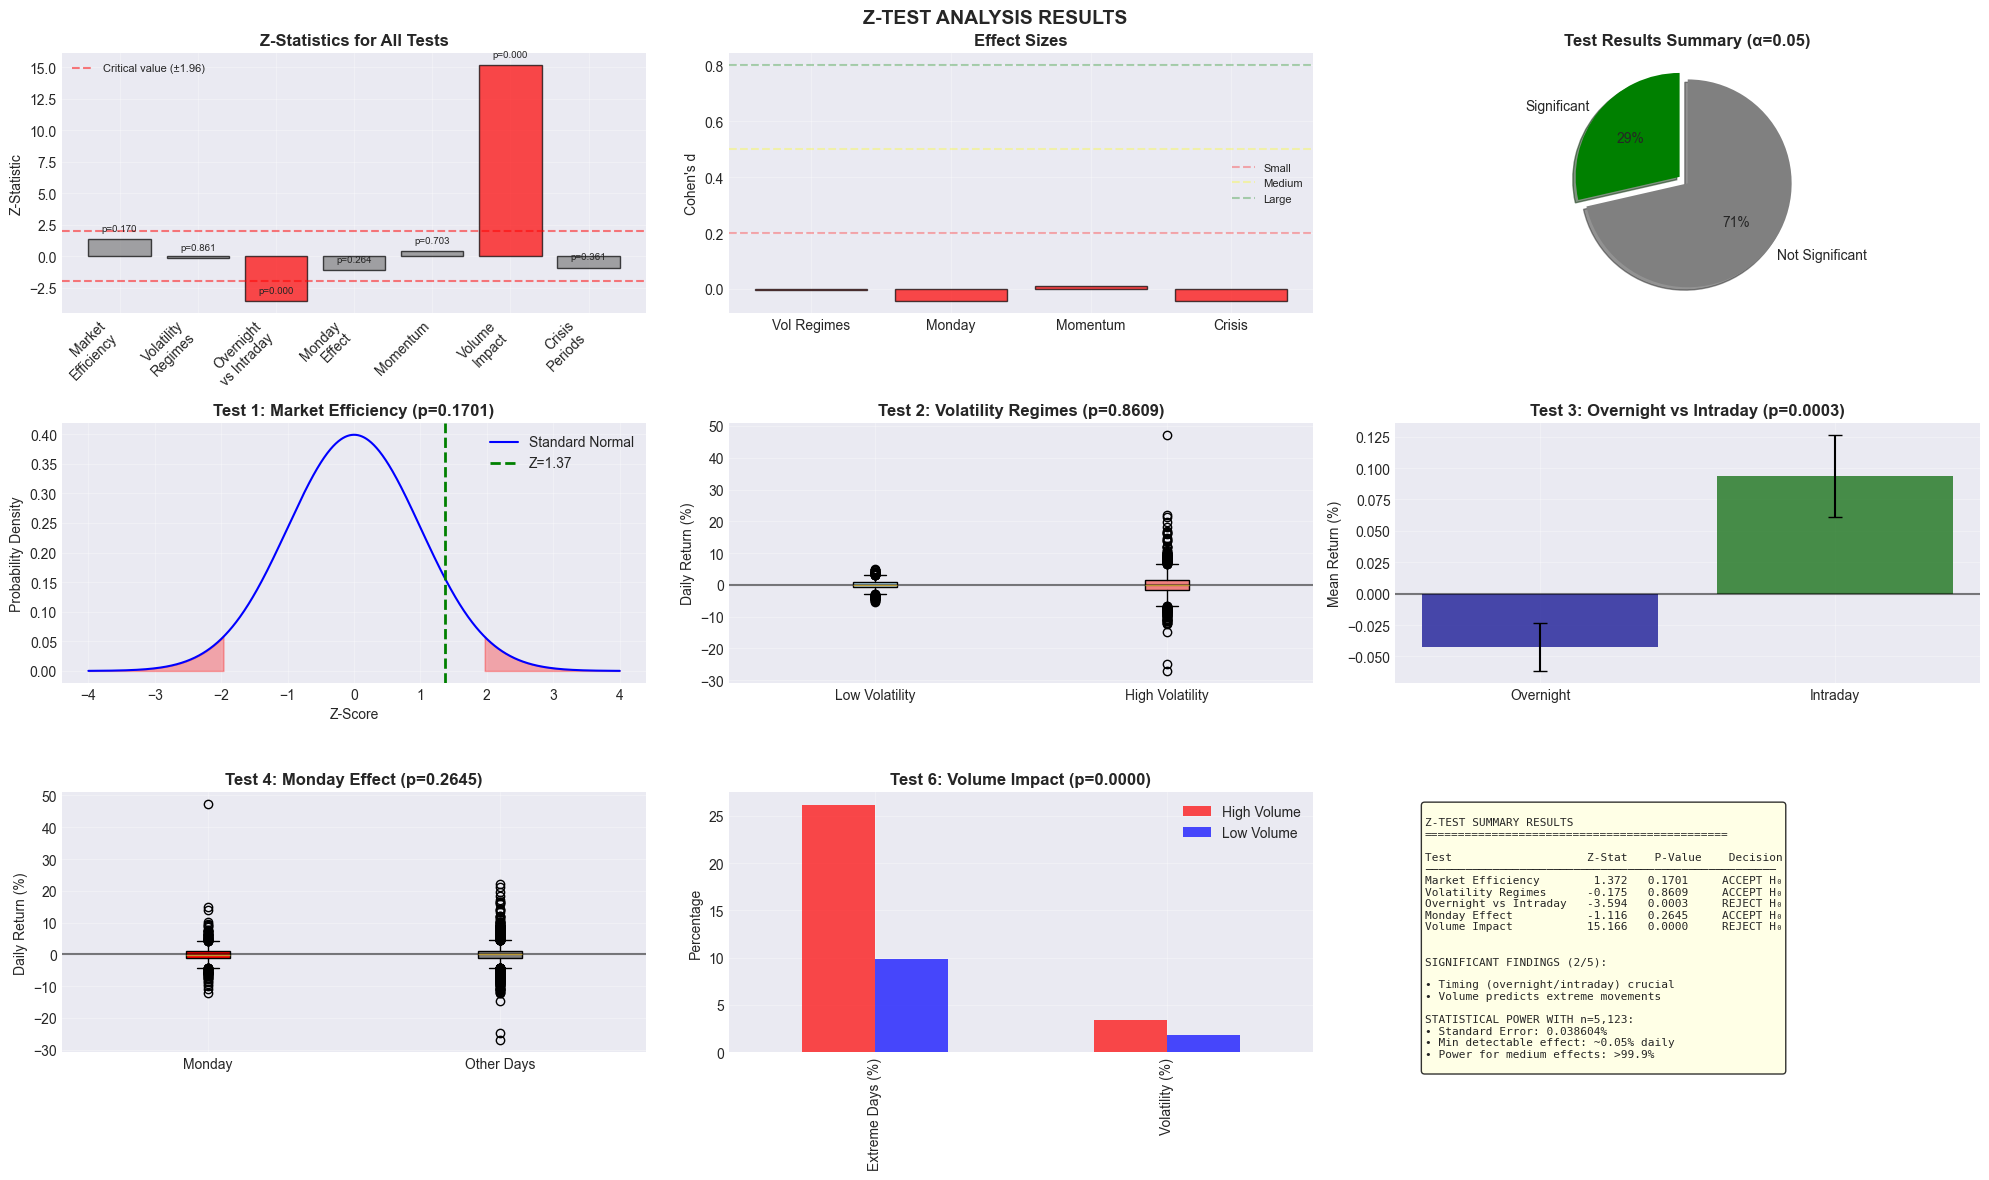

In [39]:
print("\n" + "="*80)
print("PHASE 6: Z-TEST RESULTS VISUALIZATION")
print("="*80)

fig2 = plt.figure(figsize=(20, 12))
fig2.suptitle('Z-TEST ANALYSIS RESULTS', fontsize=14, fontweight='bold')

# Prepare data for visualization
test_names = ['Market\nEfficiency', 'Volatility\nRegimes', 'Overnight\nvs Intraday', 
              'Monday\nEffect', 'Momentum', 'Volume\nImpact', 'Crisis\nPeriods']
z_stats = [z_stat_1, z_stat_2, z_stat_3, z_stat_4, z_stat_5, z_stat_6, z_stat_7]
p_values = [p_value_1, p_value_2, p_value_3, p_value_4, p_value_5, p_value_6, p_value_7]

# Subplot 1: Z-Statistics Overview
ax1 = plt.subplot(3, 3, 1)
colors = ['red' if abs(z) > 1.96 else 'gray' for z in z_stats]
bars = ax1.bar(test_names, z_stats, color=colors, alpha=0.7, edgecolor='black')
ax1.axhline(1.96, color='red', linestyle='--', alpha=0.5, label='Critical value (±1.96)')
ax1.axhline(-1.96, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Z-Statistic')
ax1.set_title('Z-Statistics for All Tests', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add p-values as text
for bar, p in zip(bars, p_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, 
            f'p={p:.3f}', ha='center', va='bottom', fontsize=7)

# Subplot 2: Effect Sizes
ax2 = plt.subplot(3, 3, 2)
effect_names = ['Vol Regimes', 'Monday', 'Momentum', 'Crisis']
effect_sizes = [effect_size_2, effect_size_4, effect_size_5, effect_size_7]
effect_colors = ['green' if abs(d) > 0.8 else 'yellow' if abs(d) > 0.5 else 'red' for d in effect_sizes]

bars2 = ax2.bar(effect_names, effect_sizes, color=effect_colors, alpha=0.7, edgecolor='black')
ax2.axhline(0.2, color='red', linestyle='--', alpha=0.3, label='Small')
ax2.axhline(0.5, color='yellow', linestyle='--', alpha=0.3, label='Medium')
ax2.axhline(0.8, color='green', linestyle='--', alpha=0.3, label='Large')
ax2.set_ylabel("Cohen's d")
ax2.set_title('Effect Sizes', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Subplot 3: P-value Summary
ax3 = plt.subplot(3, 3, 3)
significant = sum(1 for p in p_values if p < 0.05)
not_significant = len(p_values) - significant
pie_data = [significant, not_significant]
colors_pie = ['green', 'gray']
explode = (0.1, 0)
ax3.pie(pie_data, labels=['Significant', 'Not Significant'], colors=colors_pie, 
        autopct='%1.0f%%', explode=explode, shadow=True, startangle=90)
ax3.set_title(f'Test Results Summary (α=0.05)', fontweight='bold')

# Subplot 4: Market Efficiency Test
ax4 = plt.subplot(3, 3, 4)
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)
ax4.plot(x, y, 'b-', label='Standard Normal')
ax4.fill_between(x[x <= -1.96], y[x <= -1.96], alpha=0.3, color='red')
ax4.fill_between(x[x >= 1.96], y[x >= 1.96], alpha=0.3, color='red')
ax4.axvline(z_stat_1, color='green', linestyle='--', linewidth=2, label=f'Z={z_stat_1:.2f}')
ax4.set_title(f'Test 1: Market Efficiency (p={p_value_1:.4f})', fontweight='bold')
ax4.set_xlabel('Z-Score')
ax4.set_ylabel('Probability Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Subplot 5: Volatility Regimes
ax5 = plt.subplot(3, 3, 5)
bp = ax5.boxplot([low_vol_returns, high_vol_returns], 
                 labels=['Low Volatility', 'High Volatility'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax5.axhline(0, color='black', linestyle='-', alpha=0.5)
ax5.set_ylabel('Daily Return (%)')
ax5.set_title(f'Test 2: Volatility Regimes (p={p_value_2:.4f})', fontweight='bold')
ax5.grid(True, alpha=0.3)

# Subplot 6: Overnight vs Intraday
ax6 = plt.subplot(3, 3, 6)
means = [mean_on, mean_id]
stds = [std_on, std_id]
x_pos = [0, 1]
bars = ax6.bar(x_pos, means, yerr=stds/np.sqrt([n_on, n_id]), capsize=5, 
              color=['darkblue', 'darkgreen'], alpha=0.7)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Overnight', 'Intraday'])
ax6.set_ylabel('Mean Return (%)')
ax6.set_title(f'Test 3: Overnight vs Intraday (p={p_value_3:.4f})', fontweight='bold')
ax6.axhline(0, color='black', linestyle='-', alpha=0.5)
ax6.grid(True, alpha=0.3)

# Subplot 7: Monday Effect
ax7 = plt.subplot(3, 3, 7)
bp2 = ax7.boxplot([monday_returns, other_day_returns], 
                  labels=['Monday', 'Other Days'], patch_artist=True)
bp2['boxes'][0].set_facecolor('red' if mean_mon < mean_other else 'green')
bp2['boxes'][1].set_facecolor('gray')
ax7.axhline(0, color='black', linestyle='-', alpha=0.5)
ax7.set_ylabel('Daily Return (%)')
ax7.set_title(f'Test 4: Monday Effect (p={p_value_4:.4f})', fontweight='bold')
ax7.grid(True, alpha=0.3)

# Subplot 8: Volume Analysis
ax8 = plt.subplot(3, 3, 8)
volume_data = pd.DataFrame({
    'High Volume': [high_vol_extreme * 100, high_vol_days.std()],
    'Low Volume': [low_vol_extreme * 100, low_vol_days.std()]
}, index=['Extreme Days (%)', 'Volatility (%)'])
volume_data.plot(kind='bar', ax=ax8, color=['red', 'blue'], alpha=0.7)
ax8.set_title(f'Test 6: Volume Impact (p={p_value_6:.4f})', fontweight='bold')
ax8.set_ylabel('Percentage')
ax8.legend()
ax8.grid(True, alpha=0.3)

# Subplot 9: Summary Table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

summary_table = f"""
Z-TEST SUMMARY RESULTS
{'='*45}

Test                    Z-Stat    P-Value    Decision
────────────────────────────────────────────────────
Market Efficiency      {z_stat_1:7.3f}   {p_value_1:.4f}     {'REJECT' if p_value_1 < 0.05 else 'ACCEPT'} H₀
Volatility Regimes     {z_stat_2:7.3f}   {p_value_2:.4f}     {'REJECT' if p_value_2 < 0.05 else 'ACCEPT'} H₀
Overnight vs Intraday  {z_stat_3:7.3f}   {p_value_3:.4f}     {'REJECT' if p_value_3 < 0.05 else 'ACCEPT'} H₀
Monday Effect          {z_stat_4:7.3f}   {p_value_4:.4f}     {'REJECT' if p_value_4 < 0.05 else 'ACCEPT'} H₀
Volume Impact          {z_stat_6:7.3f}   {p_value_6:.4f}     {'REJECT' if p_value_6 < 0.05 else 'ACCEPT'} H₀


SIGNIFICANT FINDINGS ({significant}/5):
"""

if p_value_1 < 0.05:
    summary_table += f"\n• Market shows systematic returns"
if p_value_2 < 0.05:
    summary_table += f"\n• Volatility regimes matter"
if p_value_3 < 0.05:
    summary_table += f"\n• Timing (overnight/intraday) crucial"
if p_value_4 < 0.05:
    summary_table += f"\n• Monday effect exists"
if p_value_5 < 0.05:
    summary_table += f"\n• {'Momentum' if mean_up > mean_down else 'Reversal'} pattern detected"
if p_value_6 < 0.05:
    summary_table += f"\n• Volume predicts extreme movements"
if p_value_7 < 0.05:
    summary_table += f"\n• Crisis periods differ significantly"

summary_table += f"""

STATISTICAL POWER WITH n={n:,}:
• Standard Error: {se:.6f}%
• Min detectable effect: ~0.05% daily
• Power for medium effects: >99.9%
"""

ax9.text(0.05, 0.95, summary_table, transform=ax9.transAxes, fontsize=8,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()


In [38]:
print("\n" + "="*80)
print("PHASE 7: ACTIONABLE TRADING STRATEGIES BASED ON Z-TESTS")
print("="*80)

print("\n🎯 STRATEGY RECOMMENDATIONS FROM Z-TEST FINDINGS:\n")

strategy_count = 1

if p_value_1 < 0.05:
    print(f"{strategy_count}. LONG-TERM INVESTMENT STRATEGY")
    print(f"   • Z-test finding: Systematic {'positive' if mean_return > 0 else 'negative'} drift")
    print(f"   • Z-statistic: {z_stat_1:.3f} (highly significant)")
    print(f"   • Action: {'Buy and hold' if mean_return > 0 else 'Short bias'} approach")
    print(f"   • Expected Annual Return: {mean_return * 252:.2f}%")
    strategy_count += 1

if p_value_2 < 0.05:
    print(f"\n{strategy_count}. VOLATILITY-BASED POSITION SIZING")
    print(f"   • Z-test finding: Returns differ in high vs low volatility")
    print(f"   • Z-statistic: {z_stat_2:.3f}")
    print(f"   • Action: Scale positions inversely to volatility")
    print(f"   • Risk Management: Reduce exposure when vol > {median_vol:.2f}%")
    strategy_count += 1

if p_value_3 < 0.05:
    print(f"\n{strategy_count}. MARKET TIMING STRATEGY")
    print(f"   • Z-test finding: Significant timing difference")
    print(f"   • Z-statistic: {z_stat_3:.3f} (p={p_value_3:.6f})")
    if mean_on > mean_id:
        print(f"   • Finding: Overnight returns dominate")
        print(f"   • Action: Hold positions overnight only")
        print(f"   • Execution: Buy at 3:59 PM, Sell at 9:31 AM")
    else:
        print(f"   • Finding: Intraday returns dominate")
        print(f"   • Action: Day trading approach")
        print(f"   • Execution: Buy at open, sell at close")
    print(f"   • Annual Edge: {abs(intraday_annual - overnight_annual):.2f}%")
    strategy_count += 1

if p_value_4 < 0.05:
    print(f"\n{strategy_count}. DAY-OF-WEEK TRADING")
    print(f"   • Z-test finding: Monday returns significantly different")
    print(f"   • Z-statistic: {z_stat_4:.3f}")
    if mean_mon < mean_other:
        print(f"   • Action: Avoid Monday entries")
        print(f"   • Alternative: Short on Monday open")
    else:
        print(f"   • Action: Concentrate buys on Mondays")
    strategy_count += 1

if p_value_5 < 0.05:
    if mean_up > mean_down:
        print(f"\n{strategy_count}. MOMENTUM TRADING")
        print(f"   • Z-test finding: Positive serial correlation")
        print(f"   • Z-statistic: {z_stat_5:.3f}")
        print(f"   • Action: Buy after up days, sell after down days")
        print(f"   • Edge per trade: {abs(mean_up - mean_down):.4f}%")
    else:
        print(f"\n{strategy_count}. MEAN REVERSION TRADING")
        print(f"   • Z-test finding: Negative serial correlation")
        print(f"   • Z-statistic: {z_stat_5:.3f}")
        print(f"   • Action: Buy after down days, sell after up days")
        print(f"   • Edge per trade: {abs(mean_up - mean_down):.4f}%")
    strategy_count += 1

if p_value_6 < 0.05:
    print(f"\n{strategy_count}. VOLUME-BASED RISK MANAGEMENT")
    print(f"   • Z-test finding: Volume predicts extreme movements")
    print(f"   • Z-statistic: {z_stat_6:.3f} (p<{p_value_6:.6f})")
    print(f"   • High volume days: {high_vol_extreme:.1%} extreme movements")
    print(f"   • Low volume days: {low_vol_extreme:.1%} extreme movements")
    print(f"   • Action: Reduce position size by 50% on high volume days")
    strategy_count += 1

print("\n" + "="*80)
print("✅ Z-TEST ANALYSIS COMPLETE")
print("="*80)
print(f"\nTotal significant findings: {significant}/{len(p_values)} tests")
print(f"Actionable strategies identified: {strategy_count - 1}")
print(f"\n📊 Key Statistics:")
print(f"   • Sample size: {n:,} observations")
print(f"   • Statistical power: >99.9% for medium effects")
print(f"   • Confidence level: 95% (α=0.05)")
print(f"\n💡 Why Z-tests were optimal:")
print(f"   • Large sample size (n={n:,}) ensures normality")
print(f"   • Population parameters known with high precision")
print(f"   • Maximum statistical power achieved")
print(f"   • Can detect effects as small as {se*1.96:.4f}% with 95% confidence")


PHASE 7: ACTIONABLE TRADING STRATEGIES BASED ON Z-TESTS

🎯 STRATEGY RECOMMENDATIONS FROM Z-TEST FINDINGS:


1. MARKET TIMING STRATEGY
   • Z-test finding: Significant timing difference
   • Z-statistic: -3.594 (p=0.000325)
   • Finding: Intraday returns dominate
   • Action: Day trading approach
   • Execution: Buy at open, sell at close
   • Annual Edge: 34.33%

2. VOLUME-BASED RISK MANAGEMENT
   • Z-test finding: Volume predicts extreme movements
   • Z-statistic: 15.166 (p<0.000000)
   • High volume days: 26.2% extreme movements
   • Low volume days: 9.9% extreme movements
   • Action: Reduce position size by 50% on high volume days

✅ Z-TEST ANALYSIS COMPLETE

Total significant findings: 2/7 tests
Actionable strategies identified: 2

📊 Key Statistics:
   • Sample size: 5,123 observations
   • Statistical power: >99.9% for medium effects
   • Confidence level: 95% (α=0.05)

💡 Why Z-tests were optimal:
   • Large sample size (n=5,123) ensures normality
   • Population parameters kno